<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2014/Assignment14_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 14.3: Pruning a Tree after Fitting

**Expected Time = 60 minutes**

**Total Points = 50**

This activity focuses on using pruning to avoid overfitting in the decision tree.  By default, scikit-learn offers a `cost_complexity_pruning_path` that helps decide what the optimal `ccp_alpha` hyperparameter.  In what follows, you will learn how you can use the cost complexity paths to optimize the `ccp_alpha` hyperparameter in your `DecisionTreeClassifier`.  

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)

ccp_alphas (Cost Complexity Pruning Alpha): This is a non-negative pruning parameter used in decision trees. A larger ccp_alpha value results in more pruning, leading to a smaller, simpler tree. When ccp_alpha = 0, the tree is not pruned at all. As ccp_alpha increases, branches that provide less improvement in impurity (relative to the cost complexity) are pruned.

impurities: In the context of decision trees, impurity (often Gini impurity or entropy) measures the homogeneity of the labels at a given node. A node with high impurity contains a mix of different classes, while a node with low impurity (closer to zero) is more homogeneous, ideally containing only one class.

How they help in constructing the decision tree model:

dtree.cost_complexity_pruning_path(X, y) computes a sequence of ccp_alpha values and the corresponding total impurity of the leaves for the trees pruned at each alpha. This path allows you to:

Understand Tree Complexity: As ccp_alpha increases, the tree becomes simpler (fewer nodes, shallower depth), and typically, the total impurity of its leaves will increase (as more homogeneous sub-trees are pruned).
Prevent Overfitting: By analyzing how training and testing accuracy (or other metrics) change along this path, you can select an optimal ccp_alpha value. This value helps you find the sweet spot where the tree generalizes well to unseen data (i.e., avoids overfitting the training data) without being overly simplistic (underfitting). You typically choose the ccp_alpha that maximizes performance on a validation or test set.
In essence, ccp_alphas and impurities provide the necessary information to perform effective post-pruning on a decision tree, optimizing its complexity for better generalization.



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import Pipeline
import seaborn as sns

### The Data

For this exercise, you will use the iris data from the videos.  Again, the goal is to predict the species of flower using measurements of the plant.  Below, the data is loaded, cleaned, and split for you.

In [15]:
iris = sns.load_dataset('iris')

In [16]:
X = iris.drop(['species'], axis = 1)
y = iris['species']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 22)

[Back to top](#-Index)

### Problem 1

#### Extracting the path

**10 Points**

Below, fit a `DecisionTreeClassifier` on the training data `X_train` and `y_train` with all default parameters and `random_state = 42`.  

Use the `.cost_complexity_pruning_path()` method on the estimator with arguments equal to the taining data. Assign the results to the variable `path` below.

In [18]:
### GRADED

# YOUR CODE HERE
dtree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
path = dtree.cost_complexity_pruning_path(X_train, y_train)
# Answer check
path
df= pd.DataFrame({"ccp_alphas":path.ccp_alphas, "impurities":path.impurities})
df

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.008681,0.017361
2,0.011905,0.029266
3,0.017332,0.046598
4,0.020185,0.066782
5,0.259049,0.325832
6,0.340463,0.666295


[Back to top](#-Index)

### Problem 2

#### The `ccp_alphas` and `impurities`

**10 Points**

Your `path` variable now contains a collection of `ccp_alpha` values that control the pruning and the associated impurities for each prune.  

Assign the result of the `ccp_alpha` method on `path` to  the variable `ccp_alphas`. Use the `impurities` method on `path` and assign the result to the variable `impurities` below.  

Note, the plot of the alphas again impurities demonstrates that the full tree has total impurity 0 and increases until the tree with only a single node.  Uncomment the code to visualize the results.

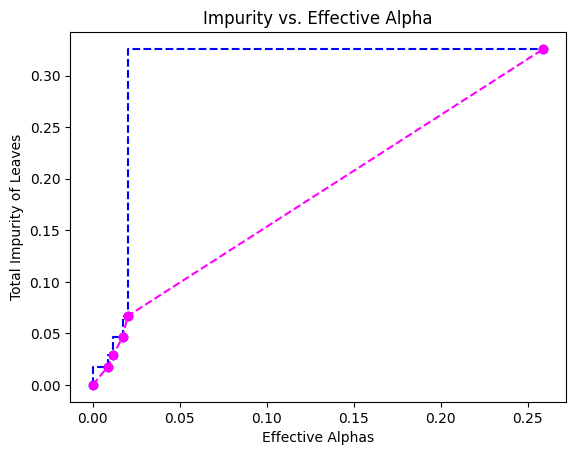

In [27]:
### GRADED
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# YOUR CODE HERE


## Answer check
plt.step(ccp_alphas[:-1], impurities[:-1], '--o', color='blue')
plt.plot(ccp_alphas[:-1], impurities[:-1], '--o', color='magenta')
plt.title('Impurity vs. Effective Alpha')
plt.xlabel('Effective Alphas')
plt.ylabel('Total Impurity of Leaves');

In [29]:
impurities[:-1], ccp_alphas[:-1]

(array([0.        , 0.01736111, 0.02926587, 0.04659781, 0.06678248,
        0.3258317 ]),
 array([0.        , 0.00868056, 0.01190476, 0.01733193, 0.02018468,
        0.25904922]))

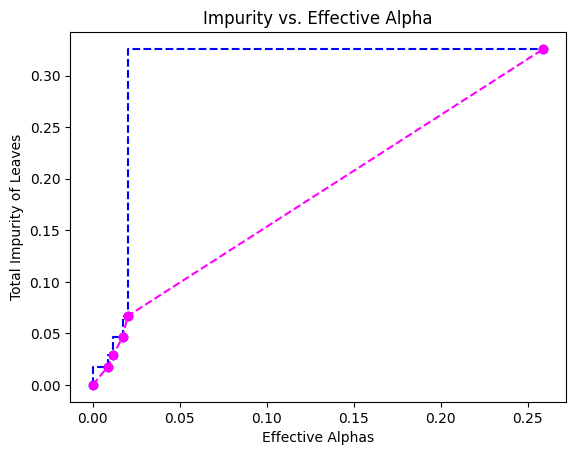

In [30]:
## Answer check
plt.step(ccp_alphas[:-1], impurities[:-1], '--o', color='blue')
plt.plot(ccp_alphas[:-1], impurities[:-1], '--o', color='magenta')
plt.title('Impurity vs. Effective Alpha')
plt.xlabel('Effective Alphas')
plt.ylabel('Total Impurity of Leaves');

[Back to top](#-Index)

### Problem 3

#### How the Nodes change with alpha

**10 Points**


Now, loop over the `ccp_alphas` and build a `DecisionTreeClassifier` with `random_state = 42` and `ccp_alpha = i` where `i` is the given alpha. Fit each estimator to the training data. Inside the loop, keep track of the fit tree node count using the `.tree_.node_count` attribute and store it the list `nodes`.



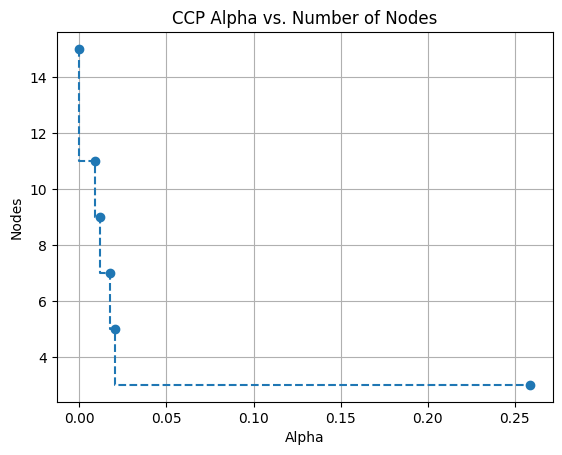

In [58]:
### GRADED
nodes = []
for i in ccp_alphas[:-1]:
    #create decision tree and fit it
    dtree_alpha=DecisionTreeClassifier(random_state=42, ccp_alpha=i).fit(X_train, y_train)
    #append node count to nodes
    nodes.append(dtree_alpha.tree_.node_count)
    pass
# YOUR CODE HERE


## Answer check
plt.step(ccp_alphas[:-1], nodes, '--o')
plt.xlabel('Alpha')
plt.ylabel('Nodes')
plt.title('CCP Alpha vs. Number of Nodes')
plt.grid();

[Back to top](#-Index)

### Problem 4

#### Depth of tree as alpha increases

**10 Points**

Repeat the above exercise this time extracting and tracking the depth of the tree using the `.get_depth()` method.  Uncomment the code to visualize the relationship.  

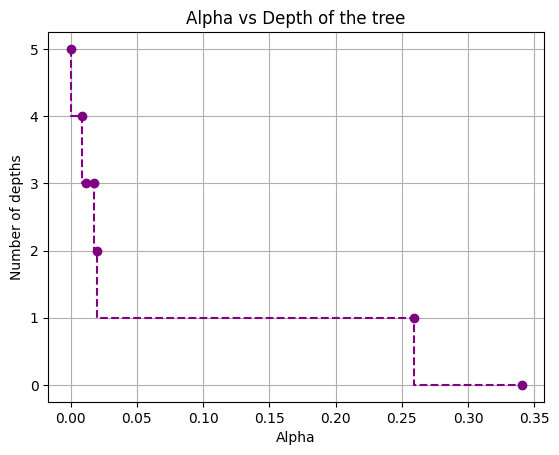

In [41]:
### GRADED
depths = []
# YOUR CODE HERE
for i in ccp_alphas:
    dtree= DecisionTreeClassifier(random_state=42,ccp_alpha=i).fit(X_train, y_train)
    depths.append(dtree.get_depth())
    pass

## Answer check
plt.step(ccp_alphas , depths ,"--o", color ='purple')
plt.xlabel("Alpha")
plt.ylabel("Number of depths")
plt.title("Alpha vs Depth of the tree")
plt.grid()

[Back to top](#-Index)

### Problem 5

#### Scoring the trees

**10 Points**

Finally, loop over the `ccp_alphas` building a tree for each and recording its training and testing accuracy to `train_accs` and `test_accs` below.  What `ccp_alpha` value resulted in the highest accuracy on the test data?  Uncomment the code to view the plot of the results.

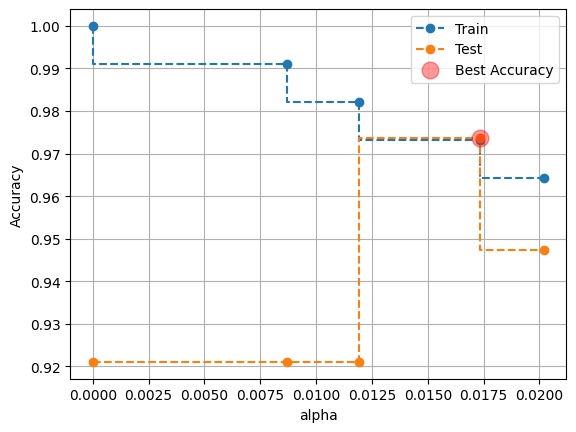

In [66]:
from sklearn.metrics import accuracy_score
### GRADED
train_accs = []
test_accs = []
# YOUR CODE HERE
for i in ccp_alphas[:-1]:
  dtree=DecisionTreeClassifier(random_state=42, ccp_alpha = i).fit(X_train, y_train)
  y_preds_test= dtree.predict(X_test)
  y_preds_train=dtree.predict(X_train)
  train_accs.append(dtree.score(X_train,y_train))
  test_accs.append(dtree.score(X_test,y_test))
  pass

# # Answer check
plt.step(ccp_alphas[:-2], train_accs[:-1], '--o', label = 'Train')
plt.step(ccp_alphas[:-2], test_accs[:-1], '--o', label = 'Test')
plt.plot(ccp_alphas[np.argmax(test_accs)], max(test_accs), 'ro', markersize = 12, alpha = 0.4, label = 'Best Accuracy')
plt.legend()
plt.grid()
plt.xlabel('alpha')
plt.ylabel('Accuracy');

In [62]:
### BEGIN HIDDEN TESTS
train_accs_ = []
test_accs_ = []
for i in ccp_alphas[:-1]:
    dtree = DecisionTreeClassifier(random_state=42, ccp_alpha=i).fit(X_train, y_train)
    train_accs_.append(dtree.score(X_train, y_train))
    test_accs_.append(dtree.score(X_test, y_test))
#
#
#
assert train_accs == train_accs_
assert test_accs == test_accs_
### END HIDDEN TESTS

In [63]:
test_accs

[0.9210526315789473,
 0.9210526315789473,
 0.9210526315789473,
 0.9736842105263158,
 0.9473684210526315,
 0.631578947368421]

For more examples of using Cost Complexity Pruning in scikitlearn see the example documentation [here](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html), and for more details on how the algorithm determines where to prune and how to compute alpha see [here](http://mlwiki.org/index.php/Cost-Complexity_Pruning).  

In [70]:
ccp_alphas[np.argmax(test_accs)], test_accs, ccp_alphas

(np.float64(0.01733193277310924),
 [0.9210526315789473,
  0.9210526315789473,
  0.9210526315789473,
  0.9736842105263158,
  0.9473684210526315,
  0.631578947368421],
 array([0.        , 0.00868056, 0.01190476, 0.01733193, 0.02018468,
        0.25904922, 0.34046294]))

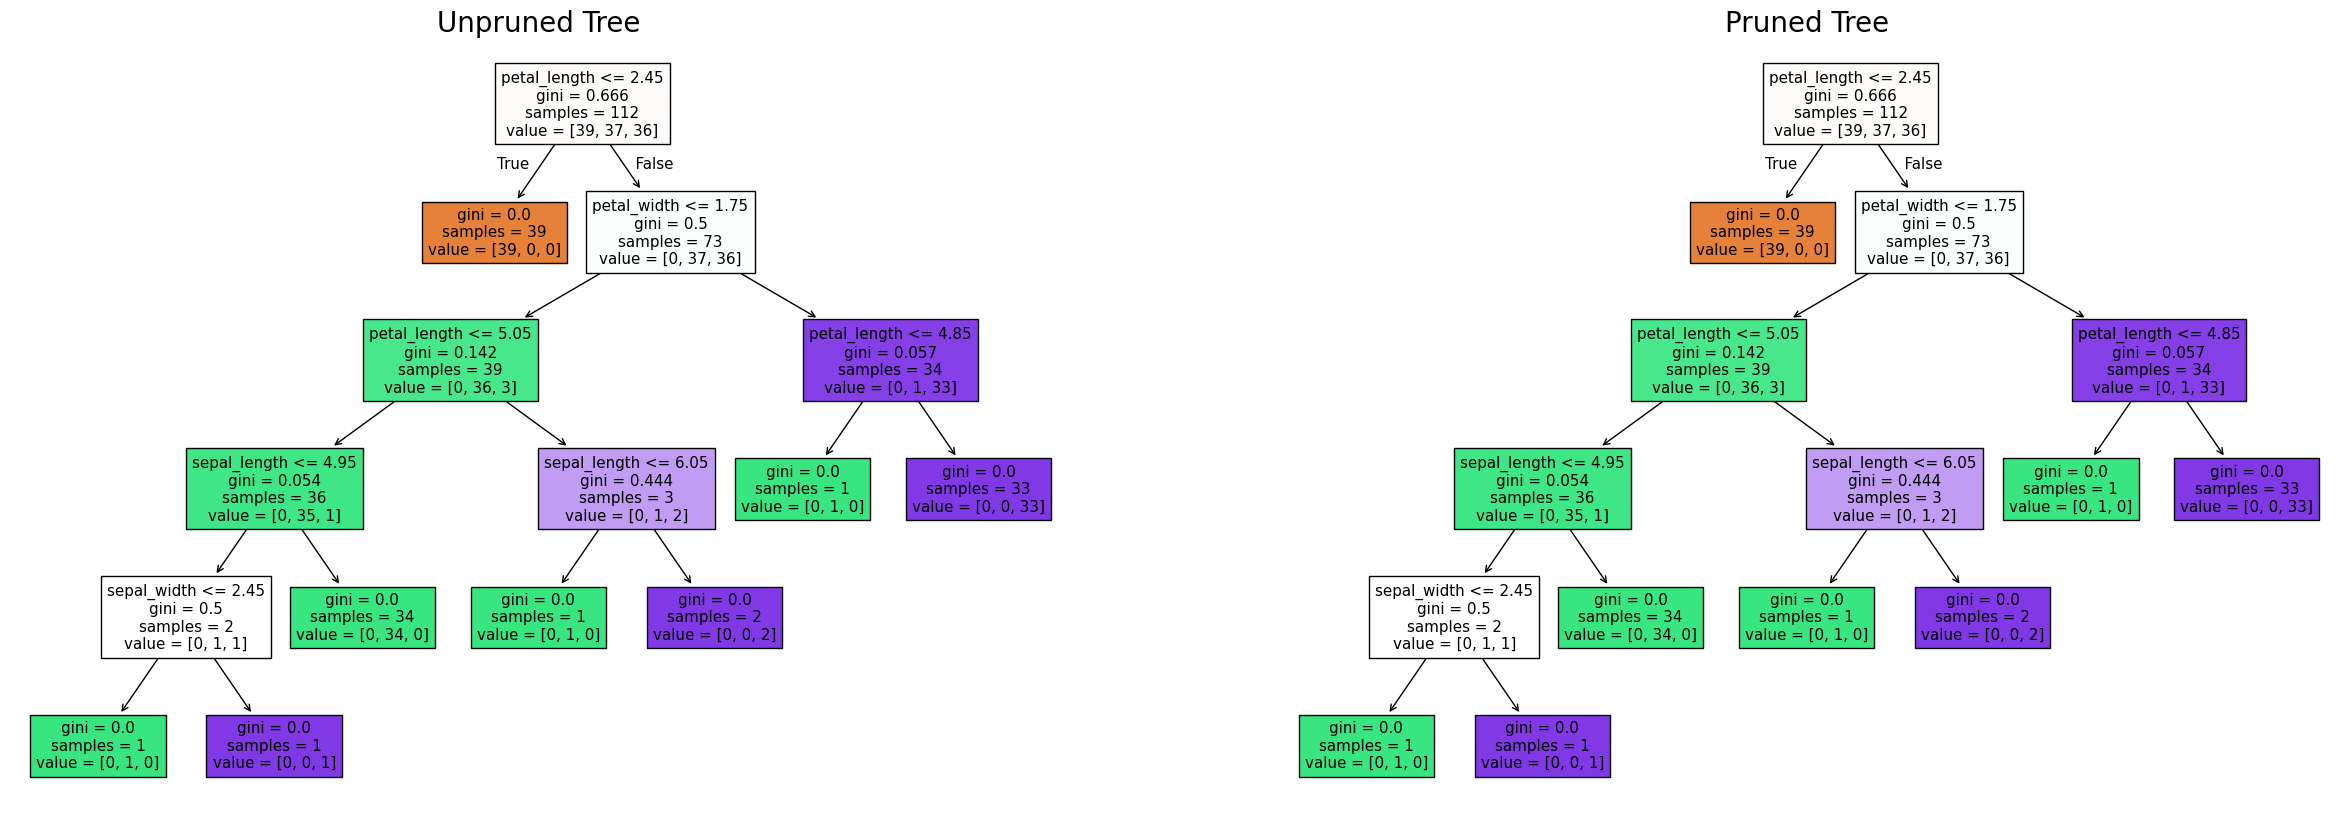

In [52]:
fig, ax = plt.subplots(1,2, figsize = (30, 10))
plot_tree(DecisionTreeClassifier(random_state=42).fit(X_train, y_train), ax = ax[0], filled = True, feature_names=X.columns);
ax[0].set_title('Unpruned Tree', fontsize = 20)
plot_tree(DecisionTreeClassifier(random_state = 42, ccp_alpha=ccp_alphas[np.argmax(test_accs)]).fit(X_train, y_train), filled = True, feature_names = X.columns);
ax[1].set_title('Pruned Tree', fontsize = 20);

In [67]:
### BEGIN HIDDEN TESTS
train_accs_ = []
test_accs_ = []
for i in ccp_alphas[:-1]:
    dtree = DecisionTreeClassifier(random_state=42, ccp_alpha=i).fit(X_train, y_train)
    train_accs_.append(dtree.score(X_train, y_train))
    test_accs_.append(dtree.score(X_test, y_test))
#
#
#
print(train_accs)
print(train_accs_)
assert train_accs == train_accs_
assert test_accs == test_accs_
### END HIDDEN TESTS

[1.0, 0.9910714285714286, 0.9821428571428571, 0.9732142857142857, 0.9642857142857143, 0.6785714285714286]
[1.0, 0.9910714285714286, 0.9821428571428571, 0.9732142857142857, 0.9642857142857143, 0.6785714285714286]
